# Assignment 2 - Image Captioning

This notebook contains the required task for the second assignment of the Deep Network Development course. Read the task description and fill in the empty code cells. Each section represents an implementation stage of image captioning : -from loading and inspecting the dataset; -to implementing, training and evaluating an Encoder-Decoder + Attention based architecture. The sections are there to guide you but you do not have to follow them strictly.

Copy this notebook to your drive (File -> Save a copy in Drive), edit it, and upload the final .ipynb file to [Canvas](https://canvas.elte.hu). If you are using this in Google Colab notebook, save it as .ipynb and upload it, or share the public link. If you have your own machine with Jupyter installed, you can work there as well, as long as you save and upload the .ipynb file.


## General Rules
Please check all the requirements listed on Canvas, but here are some general rules:
- From the provided Flickr8k dataset, split it into train, val and test sets;
- Use the train set to train an Image Captioning model, the val set for validation of the model and hyper-parameters, and the test set to evaluate the final trained model;
- For this assignment, we will give importance to the performance of your model, meaning that, we will evaluate if your model is overfitted or underfitted. For that, please include visualizations (print and plot) loss values for the split sets, as well as the metric results;
- For the metric, while we do not require high performance, we still expect better than random guessing results;
- For the comparison, you are free to choose any pre-trained model;
- Copying others' code will make you fail the assignment automatically, resulting in a 0;
- Not submitting anything results in a 0;
- Submitting something, as long as it is not an empty notebook, might result in a 1;
- **Deadline is May 15th Wednesday 11:59 PM** (strict, no late submission);
- Feel free to add more code cells as needed. But don't put code into external Python files;
- Please add your name, Neptun ID, and task details below.

**Name:**  Rafig Babayev
**Neptun ID:** GYDY2I

## Task description

Your task is to train your own custom image captioning model and compare its performance with an existing (pre-trained) model. For that, first you need to load the provided Flickr8k dataset, split into train, val and test sets. Then, create your own architecture, which should follow an Encoder-Decoder + Attention sturcture. You can use pre-trained backbones (i.e. ResNet) for the encoder, but they have to be fine-tuned. We expect you to use an Attention layer, in order to visualize how the network learned (see more details on section 2 of the notebook).
There is no expected high performance, but **your metrics should show results better than random guessing and your loss has to decrease throughout the epochs. Please use BLEU score as the metric**. We expect you to show visualizations (prints and plots) of the metrics, losses, and predictions. Use techniques to avoid overfitting such as Early stopping, and more, and save the best model while training your architecture.

**In order to get your grade for the assignment, you must defend it by answering questions during the designated practice time.**

## Guidelines
Please carefully read each cell of the notebook, as they contain guidelines to help you complete the assignments. While you don't have to follow them strictly, we believe that they provide enough help.

# 0. Necessary Imports
Import all the necessary packages for this assignment. **ONLY PYTORCH MODELS ARE ACCEPTED!**

In [1]:
# ADD YOUR CODE HERE
import torch

# 1. DATASET
For this assignment you will be using the [Flickr8k](https://www.kaggle.com/datasets/adityajn105/flickr8k) dataset, which contains captions/descriptions of different images.

### 1.1. Download dataset
The best way to download this dataset is through Kaggle.
First create a token, download it and upload it here. Follow these steps: https://www.kaggle.com/discussions/general/74235

In [2]:
!pip install -q kaggle

ERROR: Operation cancelled by user


In [3]:
from google.colab import files
files.upload()

KeyboardInterrupt: 

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d adityajn105/flickr8k

In [ ]:
!unzip flickr8k.zip

### 1.2. Load dataset
In order to load the dataset, you need to create a pytorch Dataset class.
The class should return images and captions. Remember that the captions should be returned as tokens. Do not forget to include the SOS:start of sentence, EOS:end of sentence and UNK:unknown tokens. You may want to build a vocabulary class in order to save all the words in your dataset, because your model can only predict words in your vocabulary. You do not have to save every word in your vocabulary, it is common practice to save only those words that appear multiple times in your whole dataset. For example, save only words that appear at least 5 times in your whole dataset.

In [2]:
# ADD YOUR CODE HERE
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms
class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_file, transform=None, freq_threshold=5):
        """
        Args:
            root_dir (str): Directory with all the images.
            captions_file (str): Path to the captions CSV file.
            transform (callable, optional): Optional transform to be applied on a sample.
            freq_threshold (int): Minimum frequency required for a word to be included in the vocabulary.
        """
        self.root_dir = root_dir
        self.df = pd.read_csv(captions_file)
        self.transform = transform

        # Initialize vocabulary and build it
        self.vocab = Vocabulary(freq_threshold)
        self.vocab.build_vocab(self.df['caption'])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx, 0]
        img_name = os.path.join(self.root_dir, img_id)
        image = Image.open(img_name).convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        caption = self.df.iloc[idx, 1]
        caption_vec = self.vocab.vectorize_caption(caption)

        return image, torch.tensor(caption_vec)


class Vocabulary:
    def __init__(self, freq_threshold):
        self.freq_threshold = freq_threshold
        self.word2idx = {"<SOS>": 0, "<EOS>": 1, "<UNK>": 2}  # Start of sentence, end of sentence, unknown tokens
        self.idx2word = {0: "<SOS>", 1: "<EOS>", 2: "<UNK>"}
        self.idx = 3  # Start indexing from 3
        self.vocab_size = 0
        self.word_freq = {}

    def build_vocab(self, captions):
        for caption in captions:
            for word in caption.split():
                self.word_freq[word] = self.word_freq.get(word, 0) + 1

        for word, freq in self.word_freq.items():
            if freq >= self.freq_threshold:
                self.word2idx[word] = self.idx
                self.idx2word[self.idx] = word
                self.idx += 1

        # Calculate vocab_size
        self.vocab_size = len(self.word2idx)

    def vectorize_caption(self, caption):
        vec = [self.word2idx.get(word, self.word2idx["<UNK>"]) for word in caption.split()]
        vec.insert(0, self.word2idx["<SOS>"])
        vec.append(self.word2idx["<EOS>"])
        return vec

Example output from dataset class

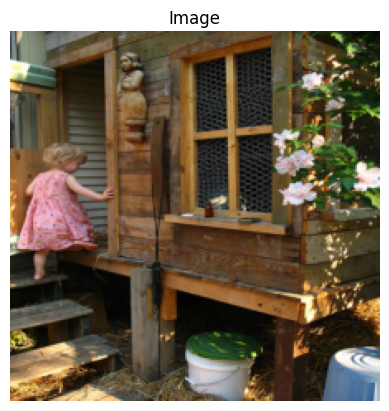

Token: tensor([ 0,  3,  4,  5,  6,  7,  8,  9, 10, 11,  6, 12, 13, 14,  5, 15,  2, 16,
        17,  1])
Sentence:
['<SOS>', 'A', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an', '<UNK>', 'way', '.', '<EOS>']


In [17]:
# ADD YOUR CODE HERE
import matplotlib.pyplot as plt

# Instantiate the dataset
dataset = FlickrDataset(root_dir='/content/Images',
                        captions_file='/content/captions.txt',
                        transform=transforms.Compose([
    transforms.Resize((224, 224)),  # Resize the image to 224x224
    transforms.RandomCrop(224),
    transforms.ToTensor()
]),# Convert the image to a PyTorch tensor
                        freq_threshold=5)
def show_image(image, title):
    """Show image"""
    plt.imshow(image.permute(1, 2, 0))
    plt.title(title)
    plt.axis('off')
    plt.show()

# Show some visualizations of the created dataset
img, caps = dataset[0]
show_image(img,"Image")
print("Token:",caps)
print("Sentence:")
print([dataset.vocab.idx2word[token] for token in caps.tolist()])

Split your dataset into train, val and test sets

In [100]:
# ADD YOUR CODE HERE
from torch.utils.data import random_split

# Define the sizes of the splits
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

# Split the dataset
train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

# Print the sizes of the splits
print(f"Training set size: {len(train_set)}")
print(f"Validation set size: {len(val_set)}")
print(f"Test set size: {len(test_set)}")


Training set size: 32364
Validation set size: 4045
Test set size: 4046


Create a dataloader, in order to load the examples in batches. Remember that, a batch has different examples, and each example (caption) may have different sizes. Therefore, consider padding techniques for the captions. For the image, use transforms in the previous step, to ensure same format and size.  

Batch 1:


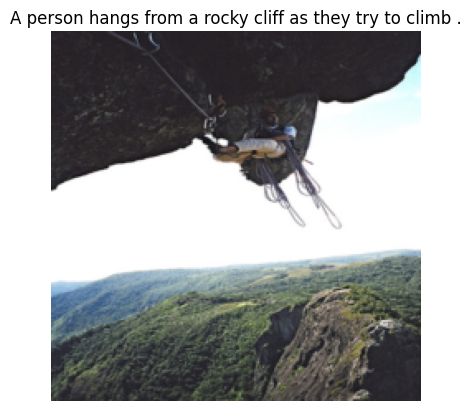

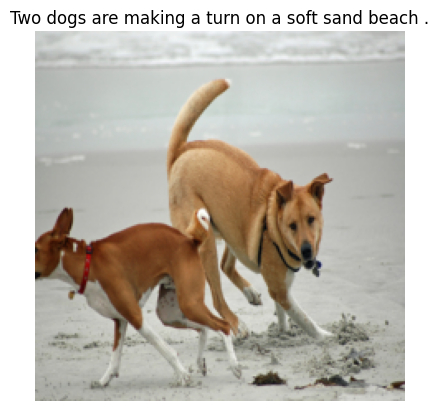

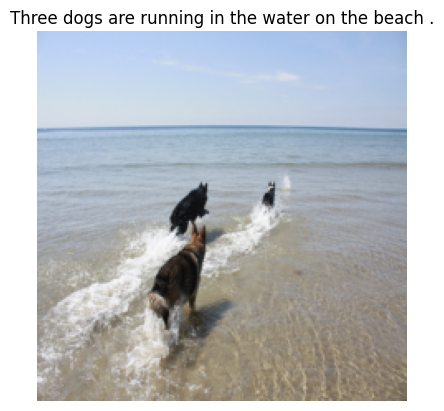

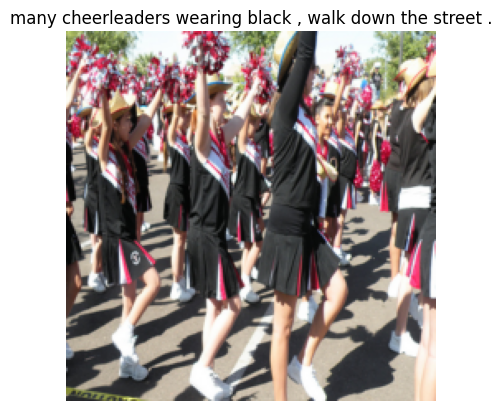

In [45]:
# ADD YOUR CODE HERE
# Example with batch=4
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import random

def collate_fn(batch):
    # Sort batch by caption length for packing
    batch.sort(key=lambda x: len(x[1]), reverse=True)
    images, captions = zip(*batch)

    # Stack images into a batch tensor
    images = torch.stack(images, dim=0)

    # Pad captions to the same length
    padded_captions = pad_sequence(captions, batch_first=True, padding_value=0)

    return images, padded_captions

# Example DataLoader with batch size 4
batch_size = 4
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

# Iterate through the DataLoader
for batch_idx, (images, captions) in enumerate(train_loader):
    print(f"Batch {batch_idx + 1}:")
    for i in range(batch_size):
        # Display the image
        plt.imshow(images[i].permute(1, 2, 0))

        # Remove <SOS> and <EOS> tokens from the caption
        caption = [dataset.vocab.idx2word[token] for token in captions[i].tolist() if token != dataset.vocab.word2idx['<SOS>'] and token != dataset.vocab.word2idx['<EOS>']]
        caption = " ".join(caption)

        # Set caption as title
        plt.title(caption)
        plt.axis('off')
        plt.show()

    # Break after displaying one batch for demonstration
    break


#2. MODEL
For this assignment, you are required to create your own custom image captioning model and compare its performance with an existing pre-trained model.

In [6]:
#Make sure to use GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### 2.1. Custom Image Captioning model

Create an Encoder-Attention-Decoder architecture with the following details:
- the encoder should process the images, thus you can create a Convolutional based architecture or use already pre-trained models like ResNet. However, you must fine-tune the pretrained model. The encoder is responisble for extracting image features;
- the attention layer should be between the encoder and decoder. It uses the image features from the encoder in order to provide context (attention scores) to the decoder hidden layers. For simplicity use Linear layers as the attention architecture;
- the decoder should be a sequence based model (i.e. LSTM) in order to process and generate captions.

Extra:
- Extra points (counting toward the final grade) will be given to any student who implements either a Vision-based Transformer architecture or a Transformer only decoder for the decoder part.

#### Reference
Here is an example of something similar to what we want to create:
<img src="https://drive.google.com/thumbnail?id=1wdddaLit7iEyCcVy5bS505NiYzL6c-4x&sz=w1000">


In [46]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision.models as models
from torch.utils.data import DataLoader,Dataset
import torchvision.transforms as T

class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        resnet = models.resnet50(pretrained=True)
        for param in resnet.parameters():
            param.requires_grad_(False)

        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)


    def forward(self, images):
        features = self.resnet(images)                                    #(batch_size,2048,7,7)
        features = features.permute(0, 2, 3, 1)                           #(batch_size,7,7,2048)
        features = features.view(features.size(0), -1, features.size(-1)) #(batch_size,49,2048)
        return features

In [47]:
class Attention(nn.Module):
    def __init__(self, encoder_dim,decoder_dim,attention_dim):
        super(Attention, self).__init__()

        self.attention_dim = attention_dim

        self.W = nn.Linear(decoder_dim,attention_dim)
        self.U = nn.Linear(encoder_dim,attention_dim)

        self.A = nn.Linear(attention_dim,1)




    def forward(self, features, hidden_state):
        u_hs = self.U(features)     #(batch_size,num_layers,attention_dim)
        w_ah = self.W(hidden_state) #(batch_size,attention_dim)

        combined_states = torch.tanh(u_hs + w_ah.unsqueeze(1)) #(batch_size,num_layers,attemtion_dim)

        attention_scores = self.A(combined_states)         #(batch_size,num_layers,1)
        attention_scores = attention_scores.squeeze(2)     #(batch_size,num_layers)


        alpha = F.softmax(attention_scores,dim=1)          #(batch_size,num_layers)

        attention_weights = features * alpha.unsqueeze(2)  #(batch_size,num_layers,features_dim)
        attention_weights = attention_weights.sum(dim=1)   #(batch_size,num_layers)

        return alpha,attention_weights

In [53]:
class Decoder(nn.Module):
    def __init__(self,embed_size, vocab_size, attention_dim,encoder_dim,decoder_dim,drop_prob=0.3):
        super().__init__()

        #save the model param
        self.vocab_size = vocab_size
        self.attention_dim = attention_dim
        self.decoder_dim = decoder_dim

        self.embedding = nn.Embedding(vocab_size,embed_size)
        self.attention = Attention(encoder_dim,decoder_dim,attention_dim)


        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)
        self.lstm_cell = nn.LSTMCell(embed_size+encoder_dim,decoder_dim,bias=True)
        self.f_beta = nn.Linear(decoder_dim, encoder_dim)


        self.fcn = nn.Linear(decoder_dim,vocab_size)
        self.drop = nn.Dropout(drop_prob)



    def forward(self, features, captions):

        #vectorize the caption
        embeds = self.embedding(captions)

        # Initialize LSTM state
        h, c = self.init_hidden_state(features)  # (batch_size, decoder_dim)

        #get the seq length to iterate
        seq_length = len(captions[0])-1 #Exclude the last one
        batch_size = captions.size(0)
        num_features = features.size(1)

        preds = torch.zeros(batch_size, seq_length, self.vocab_size).to(device)
        alphas = torch.zeros(batch_size, seq_length,num_features).to(device)

        for s in range(seq_length):
            alpha,context = self.attention(features, h)
            lstm_input = torch.cat((embeds[:, s], context), dim=1)
            h, c = self.lstm_cell(lstm_input, (h, c))

            output = self.fcn(self.drop(h))

            preds[:,s] = output
            alphas[:,s] = alpha


        return preds, alphas

    def generate_caption(self,features,max_len=20,vocab=None):
        # Inference part
        # Given the image features generate the captions

        batch_size = features.size(0)
        h, c = self.init_hidden_state(features)  # (batch_size, decoder_dim)

        alphas = []

        #starting input
        word = torch.tensor(vocab.word2idx['<SOS>']).view(1,-1).to(device)
        embeds = self.embedding(word)


        captions = []

        for i in range(max_len):
            alpha,context = self.attention(features, h)


            #store the apla score
            alphas.append(alpha.cpu().detach().numpy())

            lstm_input = torch.cat((embeds[:, 0], context), dim=1)
            h, c = self.lstm_cell(lstm_input, (h, c))
            output = self.fcn(self.drop(h))
            output = output.view(batch_size,-1)


            #select the word with most val
            predicted_word_idx = output.argmax(dim=1)

            #save the generated word
            captions.append(predicted_word_idx.item())

            #end if <EOS detected>
            if vocab.idx2word[predicted_word_idx.item()] == "<EOS>":
                break

            #send generated word as the next caption
            embeds = self.embedding(predicted_word_idx.unsqueeze(0))

        #covert the vocab idx to words and return sentence
        return [vocab.idx2word[idx] for idx in captions],alphas


    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder_out)  # (batch_size, decoder_dim)
        c = self.init_c(mean_encoder_out)
        return h, c

Combine the encoder - attention - decoder

In [54]:
# ADD YOUR CODE HERE
import torchvision.models as models

class EncoderDecoder(nn.Module):
    def __init__(self,embed_size, vocab_size, attention_dim,encoder_dim,decoder_dim,drop_prob=0.3):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder(
            embed_size=embed_size,
            vocab_size = vocab_size,
            attention_dim=attention_dim,
            encoder_dim=encoder_dim,
            decoder_dim=decoder_dim
        )

    def forward(self, images, captions):
        features = self.encoder(images)
        outputs = self.decoder(features, captions)
        return outputs

### 2.2. Training custom model

### Important: we recommend saving the model during training, so that you can resume training later in case of any Google Colab issue or limitation

In [55]:
# ADD YOUR CODE HERE
embed_size = 300
attention_dim = 256
encoder_dim = 2048  # ResNet-50 output dimension
decoder_dim = 512
#Example of how to save a model (call this in the training loop)
def save_model(model,num_epochs):
    model_state = {
        'embed_size':embed_size,
        'attention_dim':attention_dim,
        'encoder_dim':encoder_dim,
        'decoder_dim':decoder_dim,
        'state_dict':model.state_dict()
    }

    torch.save(model_state,'image_captioning.pth')

#In case of resuming training, make sure to load the architecture first
# model = Architecture()
#and then load the weights and other params
# model.load_state_dict(model_state['state_dict'])

Pay attention to your choices. Define an optimizer, a loss function, the number of epochs and regularization techniques.
Be aware of overfitting and underfitting. Make sure the loss is decreasing over the epochs. Save the losses so that they can be visualized.

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/5], Train Loss: 5.3719, Val Loss: 4.9477
Epoch [2/5], Train Loss: 3.8552, Val Loss: 4.4854
Epoch [3/5], Train Loss: 3.3864, Val Loss: 4.2121
Epoch [4/5], Train Loss: 2.9940, Val Loss: 4.1082
Epoch [5/5], Train Loss: 2.8801, Val Loss: 3.9879


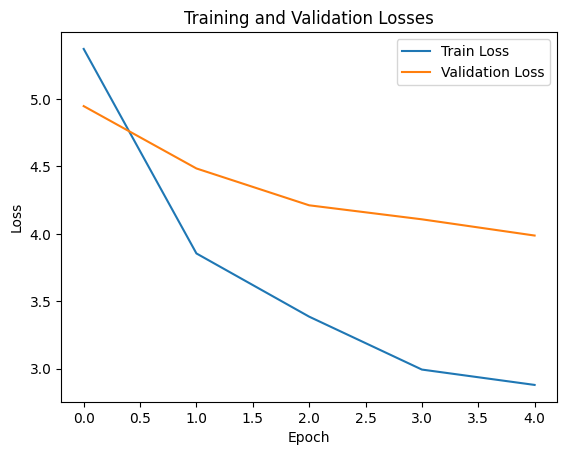

In [57]:
# ADD YOUR CODE HERE
import torch.optim as optim

learning_rate = 0.005
weight_decay = 0.0005
vocab_size = dataset.vocab.vocab_size
num_epochs = 5

# Create an instance of EncoderDecoder class
model = EncoderDecoder(embed_size,
                       vocab_size,
                       attention_dim,
                       encoder_dim,
                       decoder_dim)

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

# Define loss function
criterion = nn.CrossEntropyLoss()

# Training loop
train_losses = []
val_losses = []
for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for images, captions in train_loader:
        optimizer.zero_grad()

        # Forward pass with only images
        outputs,attentions = model(images, captions)

        # Calculate the batch loss.
        targets = captions[:,1:]
        loss = criterion(outputs.view(-1, vocab_size), targets.reshape(-1))


        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, captions in val_loader:
            outputs,attentions = model(images, captions)
             # Calculate the batch loss.
            targets = captions[:,1:]
            loss = criterion(outputs.view(-1, vocab_size), targets.reshape(-1))
            val_loss += loss.item() * images.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

    # Print epoch statistics
    print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

    # Save model checkpoint
    save_model(model, epoch + 1)


def plot_losses(train_losses, val_losses):
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Losses')
    plt.legend()
    plt.show()

# Plot losses
plot_losses(train_losses, val_losses)

**Visualize the attention weigths in order to understand how your model learned (Failure to do this, will result in losing points).
For that, use the 'context' variable returned by the Attention class to overlay them on the image.**  

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


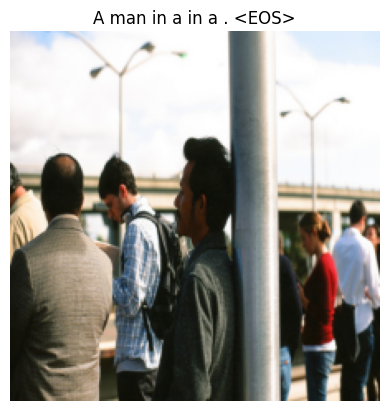

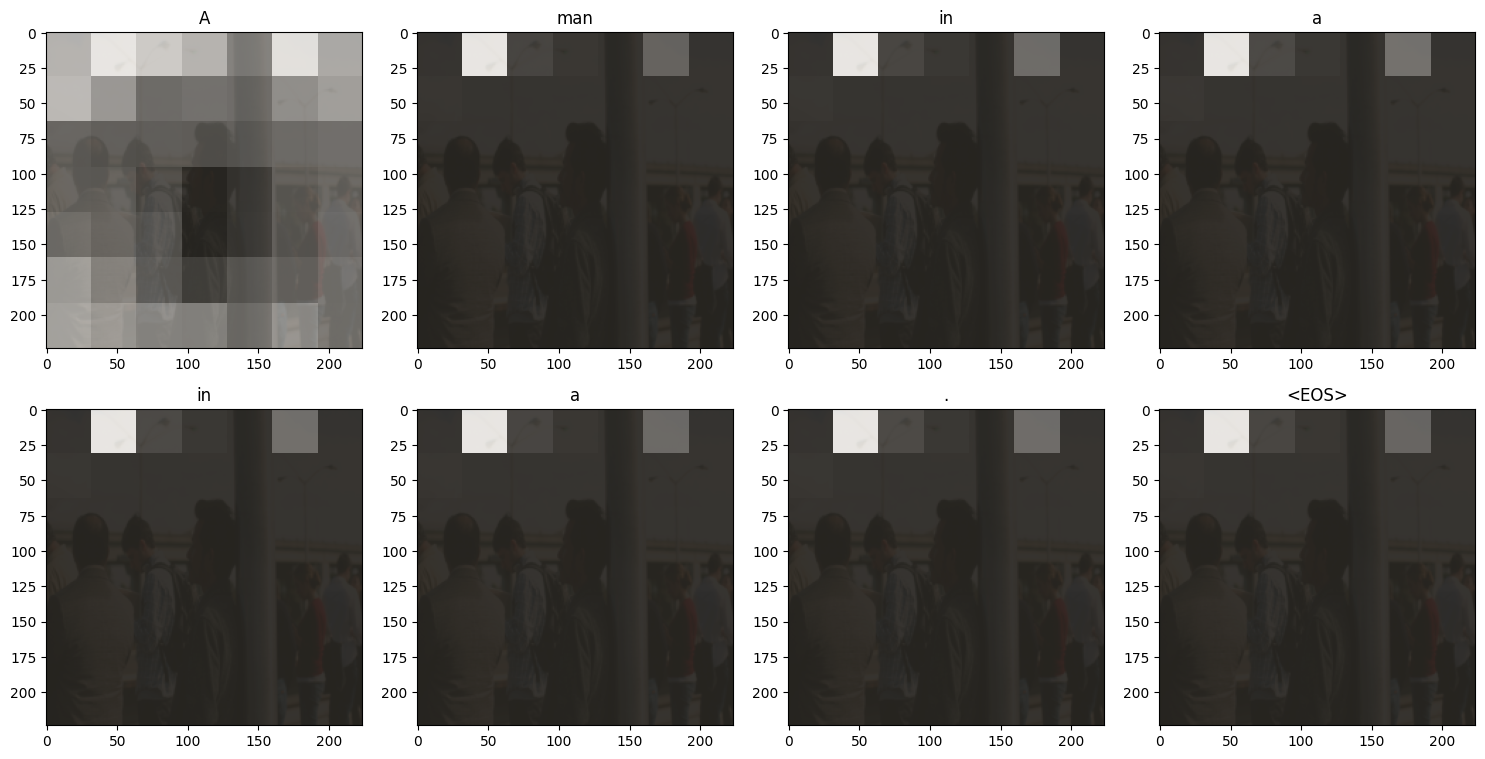

In [73]:
# ADD YOUR CODE HERE
#generate caption
def get_caps_from(features_tensors):
    #generate the caption
    model.eval()
    with torch.no_grad():
        features = model.encoder(features_tensors.to(device))
        caps,alphas = model.decoder.generate_caption(features,vocab=dataset.vocab)
        caption = ' '.join(caps)
        show_image(features_tensors[0],title=caption)

    return caps,alphas

#Show attention
def plot_attention(img, result, attention_plot):
    #untransform
    img[0] = img[0] * 0.229
    img[1] = img[1] * 0.224
    img[2] = img[2] * 0.225
    img[0] += 0.485
    img[1] += 0.456
    img[2] += 0.406

    img = img.numpy().transpose((1, 2, 0))
    temp_image = img

    fig = plt.figure(figsize=(15, 15))

    len_result = len(result)
    for l in range(len_result):
        temp_att = attention_plot[l].reshape(7,7)

        ax = fig.add_subplot(len_result//2,len_result//2, l+1)
        ax.set_title(result[l])
        img = ax.imshow(temp_image)
        ax.imshow(temp_att, cmap='gray', alpha=0.7, extent=img.get_extent())


    plt.tight_layout()
    plt.show()

#writing the dataloader
data_loader = DataLoader(
    dataset=dataset,
    batch_size=4,
    num_workers=4,
    shuffle=True,
    # batch_first=False
)

dataiter = iter(data_loader)
images,_ = next(dataiter)

img = images[0].detach().clone()
img1 = images[0].detach().clone()
caps,alphas = get_caps_from(img.unsqueeze(0))

plot_attention(img1, caps, alphas)

### 2.3. Evaluation on test set

Evaluate your trained model on the test set. Use the BLEU score as your metric: torchtext.data.metrics.bleu_score(...)

You may try BLEU-1,2 and 3.

In [98]:
!pip install torchmetrics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 14.9 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.19.3-py3-none-manylinux1_x86_64.whl (166.0 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-man

In [99]:
# ADD YOUR CODE HERE
from torchtext.data.metrics import bleu_score
from torchmetrics.text import BLEUScore


test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

# Define a function to generate captions for the test set
def generate_captions(model, test_loader):
    captions_pred = []
    captions_true = []
    model.eval()
    with torch.no_grad():
        for images, captions in test_loader:
            # Forward pass to generate captions
            outputs, attentions = model(images, captions)
            # Convert outputs to captions
            # predicted_captions = model.decoder.generate_caption(outputs, vocab=dataset.vocab)
            # Append true captions
            captions_true.extend(captions)
            # Append predicted captions
            captions_pred.extend(attentions)
    return captions_pred, captions_true

# Generate captions for the test set
predicted_captions, true_captions = generate_captions(model, test_loader)

# # Truncate or pad the predicted captions to match the length of the true captions
# if len(predicted_captions) > len(true_captions):
#     predicted_captions = predicted_captions[:len(true_captions)]
# elif len(predicted_captions) < len(true_captions):
#     # Pad the predicted captions with empty strings
#     predicted_captions += [''] * (len(true_captions) - len(predicted_captions))

# Convert each caption tensor into a list of words
# predicted_captions = [[word for word in caption.split()] for caption in predicted_captions]
# true_captions = [[word for word in caption.split()] for caption in true_captions]

# # Calculate BLEU scores
# bleu1 = bleu_score(predicted_captions, [true_captions], max_n=1, weights=[1.0])
# bleu2 = bleu_score(predicted_captions, [true_captions], max_n=2, weights=[0.5, 0.5])
# bleu3 = bleu_score(predicted_captions, [true_captions], max_n=3, weights=[0.33, 0.33, 0.33])

# Define the BLEU score metric
bleu_metric = BLEUScore()

# Calculate the BLEU score
bleu_scores = bleu_metric(predicted_captions, [true_captions])

# Plot the BLEU scores
fig, ax = bleu_metric.plot(bleu_scores)
# print(f"BLEU-1 Score: {bleu1}")
# print(f"BLEU-2 Score: {bleu2}")
# print(f"BLEU-3 Score: {bleu3}")

/usr/local/lib/python3.10/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of metric BLEUScore was called before the ``update`` method which may lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)  # noqa: B028


TypeError: BLEUScore.compute() takes 1 positional argument but 3 were given

### 2.4. Load an existing Image Captioning model
Feel free to choose any pre-trained image captioning model. For simplicity, try choosing a model already trained on Flickr8k.

In [ ]:
# ADD YOUR CODE HERE

### 2.5 Evaluate the chosen pre-trained captioning model on the test set
Use the same metrics chosen on step 2.3.

In [ ]:
# ADD YOUR CODE HERE

# 3. COMPARISON
Compare the performance of the two models. Show some visualizations of predictions from both models. Justify their differences. How would you improve your own custom model?

In [ ]:
# ADD YOUR CODE HERE